# Análisis Cuantitativo de Vulnerabilidades y Dependencias
Este notebook contiene el análisis de los SBOMs, dependencias y vulnerabilidades descubiertas en los repositorios seleccionados de la organización **`encode`**.

## Reproducibilidad
Para reproducir este análisis:
1. Haber ejecutado los scripts de obtención de datos desde el entorno Dev Container (`ciberseguridad_2026`).
2. Los resultados en formato JSON deben residir en las carpetas respectivas dentro de `ciberseguridad_2026/data/results/`.


In [1]:
import pandas as pd
import json
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
sns.set_theme(style="whitegrid")


In [4]:
RESULTS_DIR = Path("ciberseguridad_2026/data/results")
if not RESULTS_DIR.exists():
    RESULTS_DIR = Path("data/results") # Si se corre desde dentro de ciberseguridad_2026
if not RESULTS_DIR.exists():
    RESULTS_DIR = Path("entregable_final/ciberseguridad_2026/data/results") # Si se corre desde afuera
    
print(f"Buscando resultados en: {RESULTS_DIR.absolute()}")
print(f"¿Existe el directorio?: {RESULTS_DIR.exists()}")


Buscando resultados en: e:\UFRO\5to-2026\mineria-repositorio\Analisis - sboms\entregable_final\ciberseguridad_2026\data\results
¿Existe el directorio?: True


## 1. Análisis de Vulnerabilidades en Dependencias (Grype)

In [6]:
grype_data = []

if RESULTS_DIR.exists():
    for f in RESULTS_DIR.glob("*-grype.json"):
        with open(f, "r", encoding="utf-8") as file:
            data = json.load(file)
            repo_name = f.stem.replace("-grype", "")
            
            # Ahora iteramos sobre "vulnerabilities" en lugar de "matches"
            for vuln in data.get("vulnerabilities", []):
                grype_data.append({
                    "repo": repo_name,
                    "vulnerability_id": vuln.get("vuln_id"),
                    "severity": vuln.get("vuln_severity", "unknown").capitalize(),
                    "package_name": vuln.get("package_name"),
                    "package_version": vuln.get("current_version"),
                    "type": vuln.get("type", "vulnerability")
                })

df_grype = pd.DataFrame(grype_data)

if not df_grype.empty:
    display(df_grype.head())
else:
    print("No se encontraron vulnerabilidades en los JSONs cargados.")


,repo,vulnerability_id,severity,package_name,package_version,type
0,flask,GHSA-2g68-c3qc-8985,Low,werkzeug,2.3.3,vulnerability
1,flask,GHSA-f9vj-2wh5-fj8j,Low,werkzeug,2.3.3,vulnerability
2,flask,GHSA-q34m-jh98-gwm2,Low,werkzeug,2.3.3,vulnerability
3,flask,GHSA-h75v-3vvj-5mfj,Low,jinja2,3.1.2,vulnerability
4,flask,GHSA-hrfv-mqp8-q5rw,Low,werkzeug,2.3.3,vulnerability


C:\Users\diego\AppData\Local\Temp\ipykernel_5940\1872444169.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_grype, x="severity", order=["Low", "Medium", "High", "Critical"], palette="Reds")


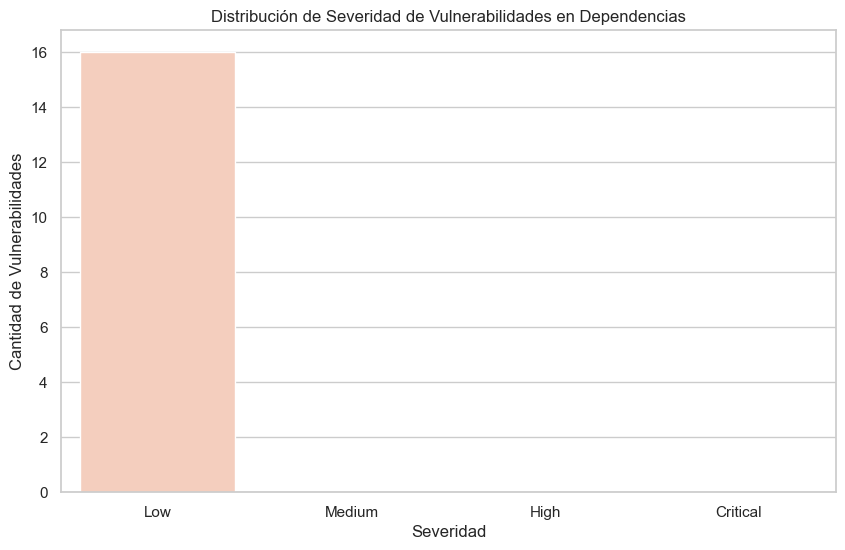

C:\Users\diego\AppData\Local\Temp\ipykernel_5940\1872444169.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_vuln_packages.values, y=top_vuln_packages.index, palette="viridis")


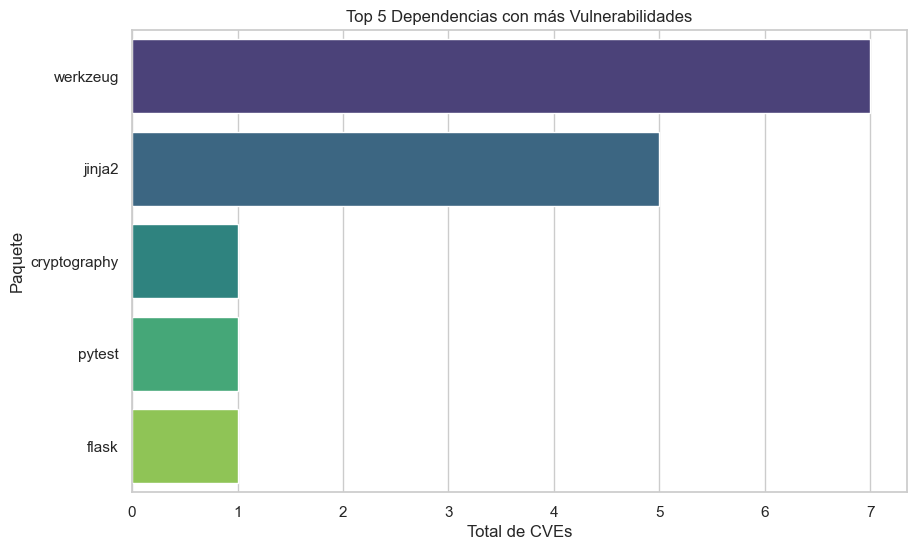

In [7]:
if not df_grype.empty:
    plt.figure(figsize=(10, 6))
    ax = sns.countplot(data=df_grype, x="severity", order=["Low", "Medium", "High", "Critical"], palette="Reds")
    plt.title("Distribución de Severidad de Vulnerabilidades en Dependencias")
    plt.ylabel("Cantidad de Vulnerabilidades")
    plt.xlabel("Severidad")
    plt.show()
    
    # Top 5 paquetes con más vulnerabilidades
    top_vuln_packages = df_grype['package_name'].value_counts().head(5)
    plt.figure(figsize=(10, 6))
    sns.barplot(x=top_vuln_packages.values, y=top_vuln_packages.index, palette="viridis")
    plt.title("Top 5 Dependencias con más Vulnerabilidades")
    plt.xlabel("Total de CVEs")
    plt.ylabel("Paquete")
    plt.show()


## 2. Análisis de Código Fuente Estático (CodeQL)

In [9]:
codeql_data = []

if RESULTS_DIR.exists():
    for f in RESULTS_DIR.glob("*-codeql.json"):
        with open(f, "r", encoding="utf-8") as file:
            data = json.load(file)
            repo_name = f.stem.replace("-codeql", "")
            
            # Iteramos sobre la nueva clave "issues"
            for issue in data.get("issues", []):
                codeql_data.append({
                    "repo": repo_name,
                    "rule_id": issue.get("rule_id"),
                    "message": issue.get("message"),
                    "severity": issue.get("level", "warning").capitalize()
                })

df_codeql = pd.DataFrame(codeql_data)

if not df_codeql.empty:
    display(df_codeql.head())
else:
    print("No se encontraron alertas en los JSONs de CodeQL.")


,repo,rule_id,message,severity
0,click,py/clear-text-logging-sensitive-data,This expression logs [sensitive data (password...,Warning
1,click,py/overly-permissive-file,Overly permissive mask in open sets file to wo...,Warning
2,click,py/redundant-comparison,"Test is always true, because of [this conditio...",Warning
3,click,py/unnecessary-lambda,This 'lambda' is just a simple wrapper around ...,Warning
4,click,py/unnecessary-lambda,This 'lambda' is just a simple wrapper around ...,Warning


C:\Users\diego\AppData\Local\Temp\ipykernel_5940\289135430.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_codeql, y="rule_id", order=df_codeql['rule_id'].value_counts().index, palette="magma")


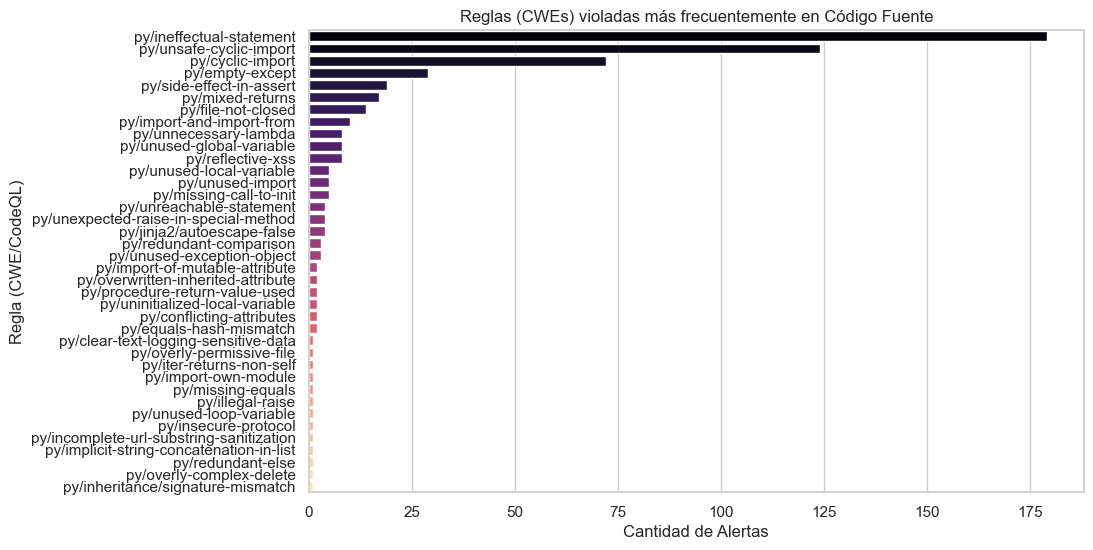

In [10]:
if not df_codeql.empty:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df_codeql, y="rule_id", order=df_codeql['rule_id'].value_counts().index, palette="magma")
    plt.title("Reglas (CWEs) violadas más frecuentemente en Código Fuente")
    plt.xlabel("Cantidad de Alertas")
    plt.ylabel("Regla (CWE/CodeQL)")
    plt.show()


## 3. Conclusiones
*(Elaborar las conclusiones una vez generados los gráficos)*
- **Estado de las Dependencias**: ¿Cuántas dependencias críticas tenemos?
- **Salud del Código (CodeQL)**: ¿Qué reglas de seguridad saltan más frecuentemente y por qué?
